# Numba compatible distributions

Test each of the Numba compatible distributions.

To open an interactive version of this notebook, click [![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/laser-base/laser-generic/HEAD?urlpath=lab%2Ftree%2Fdocs%2Ftutorials%2Fnotebooks%2Fdistributions.ipynb). Note that it may take a few minutes to create the environment and edits will not be saved.

In [ ]:
import numba as nb
import numpy as np
from matplotlib import pyplot as plt

import laser.core.distributions as distributions

import os

if "BINDER_REPO_URL" in os.environ:
    # Binder containers report the host's full core count via os.cpu_count(), which numba's
    # parallel=True kernels (used inside laser.core/laser.generic) use to size their thread pool -
    # but Binder only grants a small CPU quota, so that pool oversubscribes it and thrashes.
    # Local runs and the docs build see an accurate core count, so they're unaffected and keep
    # numba's default thread count.
    import numba

    numba.set_num_threads(1)

In [ ]:
def plot_histogram(data: list[tuple[np.ndarray, str, str]], bins: int = 101) -> None:

    for d, label, color in data:
        plt.hist(d, bins=bins, density=True, alpha=0.6, color=color, label=label)
    plt.xlabel('Value')
    plt.ylabel('Density')
    plt.title('Histogram')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


## Beta

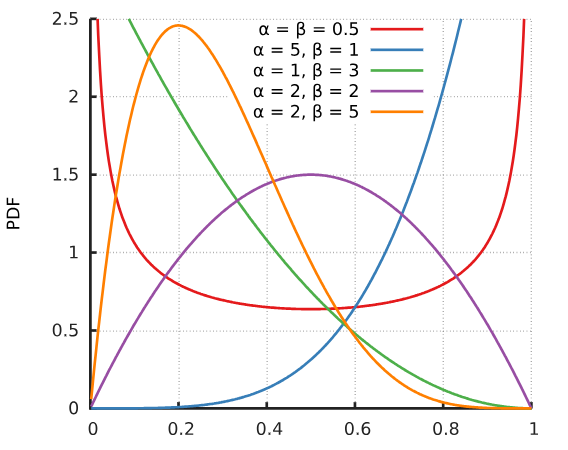

In [ ]:
NSAMPLES = np.int32(100_000)

traces = []
for alpha, beta, color in [(0.5, 0.5, "red"), (5.0, 1.0, "blue"), (1.0, 3.0, "green"), (2.0, 2.0, "purple"), (2.0, 5.0, "orange")]:

    dist = distributions.beta(a=alpha, b=beta)
    distributions.sample_floats(dist, samples := np.zeros(NSAMPLES, dtype=np.float32))

    traces.append((samples, f'Beta({alpha}, {beta})', color))

plot_histogram(traces)
plt.figtext(0.5, -0.05, 'The figure demonstrates that the Numba-compiled `distributions.beta` sampler reproduces the full Beta family — U-shaped, monotone, symmetric, and skewed regimes — within Monte-Carlo noise.', ha="center", va="top", wrap=True, fontsize=8)


## Binomial

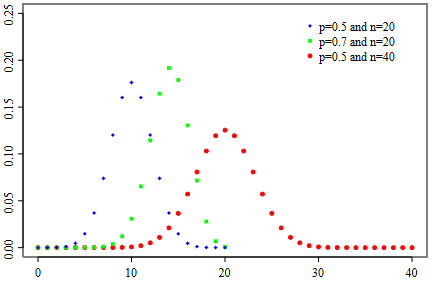


In [ ]:
NSAMPLES = np.int32(100_000)

traces = []
for p, n, color in [(0.5, 20, "blue"), (0.7, 20, "green"), (0.5, 40, "red")]:

    dist = distributions.binomial(n=n, p=p)
    distributions.sample_ints(dist, samples := np.zeros(NSAMPLES, dtype=np.int32))

    traces.append((samples, f'Binomial({n}, {p})', color))

plot_histogram(traces)
plt.figtext(0.5, -0.05, 'The figure demonstrates that the `distributions.binomial` integer sampler matches the analytic binomial PMF across small-$n$, skewed-$p$, and larger-$n$ regimes.', ha="center", va="top", wrap=True, fontsize=8)


## Exponential

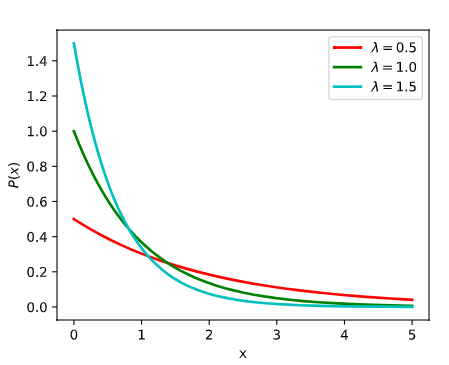


In [ ]:
NSAMPLES = np.int32(100_000)

traces = []
for lamda, color in [(0.5, "red"), (1.0, "green"), (1.5, "lightblue")]:

    dist = distributions.exponential(scale=1/lamda)
    distributions.sample_floats(dist, samples := np.zeros(NSAMPLES, dtype=np.float32))

    traces.append((samples[samples < 8], f'Exponential(1/{lamda})', color))

plot_histogram(traces)
plt.figtext(0.5, -0.05, 'The figure demonstrates that the `distributions.exponential` float sampler reproduces the memoryless exponential PDF and that its rate parameter is correctly mapped through the scale convention.', ha="center", va="top", wrap=True, fontsize=8)


## Gamma

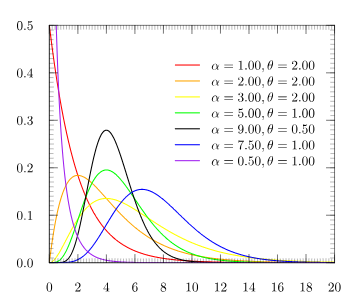

In [ ]:
NSAMPLES = np.int32(100_000)

traces = []
for alpha, theta, color in [(1.0, 2.0, "red"), (2.0, 2.0, "orange"), (3.0, 2.0, "yellow"), (5.0, 1.0, "green"), (9.0, 0.5, "black"), (7.5, 1.0, "blue"), (0.5, 1.0, "purple")]:

    dist = distributions.gamma(shape=alpha, scale=theta)
    distributions.sample_floats(dist, samples := np.zeros(NSAMPLES, dtype=np.float32))

    traces.append((samples[(samples > 0.25) & (samples <= 15)], f'Gamma({alpha}, {theta})', color))

plot_histogram(traces)
plt.figtext(0.5, -0.05, 'The figure demonstrates that the `distributions.gamma` sampler covers the full shape spectrum from monotone-decreasing ($\\alpha < 1$), through exponential ($\\alpha = 1$), to increasingly symmetric Gaussian-like humps ($\\alpha \\gg 1$), with the mean tracking $\\alpha\\theta$.', ha="center", va="top", wrap=True, fontsize=8)


## Logistic

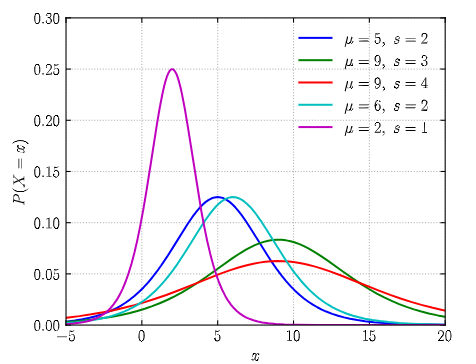


In [ ]:
NSAMPLES = np.int32(100_000)

traces = []
for mu, s, color in [(5, 2, "blue"), (9, 3, "green"), (9, 4, "red"), (6, 2, "lightblue"), (2, 1, "purple")]:

    dist = distributions.logistic(loc=mu, scale=s)
    distributions.sample_floats(dist, samples := np.zeros(NSAMPLES, dtype=np.float32))

    traces.append((samples[(samples >= -5) & (samples <= 25)], f'Logistic({mu}, {s})', color))

plot_histogram(traces)
plt.figtext(0.5, -0.05, 'The figure demonstrates that `distributions.logistic` reproduces the analytic logistic PDF with correct location $\\mu$ and scale $s$ across both narrow and broad regimes.', ha="center", va="top", wrap=True, fontsize=8)


## LogNormal

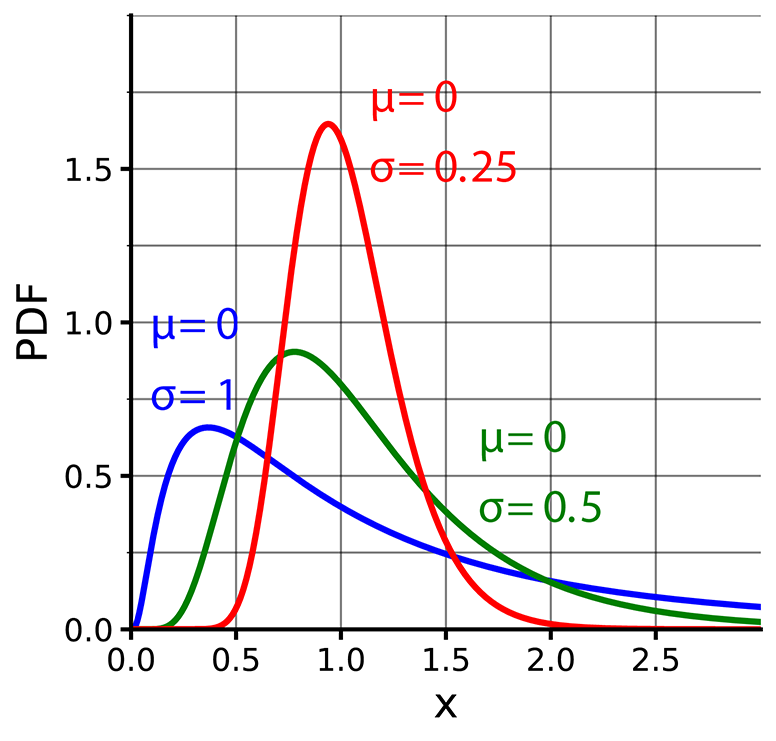


In [ ]:
NSAMPLES = np.int32(100_000)

traces = []
for mu, sigma, color in [(0, 1, "blue"), (0, 0.5, "green"), (0, 0.25, "red")]:

    dist = distributions.lognormal(mean=mu, sigma=sigma)
    distributions.sample_floats(dist, samples := np.zeros(NSAMPLES, dtype=np.float32))

    traces.append((samples[samples <= 3], f'Lognormal({mu}, {sigma})', color))

plot_histogram(traces)
plt.figtext(0.5, -0.05, 'The figure demonstrates that `distributions.lognormal` correctly produces the positively skewed lognormal PDF and that its variance parameter controls both the spread and the right-tail heaviness.', ha="center", va="top", wrap=True, fontsize=8)


## Multinomial

## NegativeBinomial

## Normal


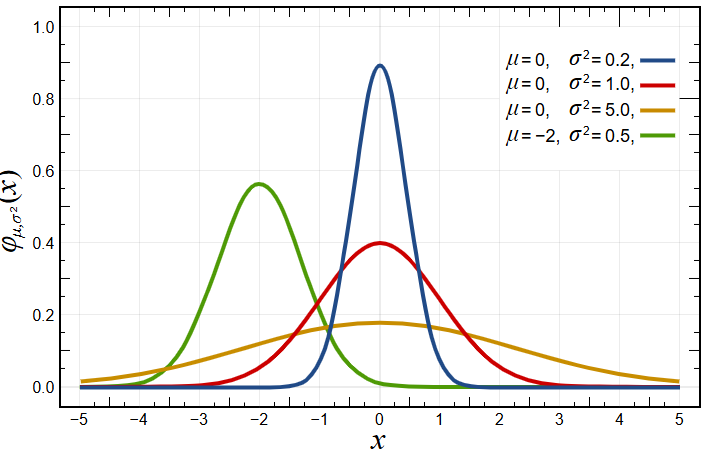

In [ ]:
NSAMPLES = np.int32(100_000)

traces = []
for mu, sigmasq, color in [(0, 0.2, "blue"), (0, 1.0, "red"), (0, 5.0, "orange"), (-2, 0.5, "green")]:

    dist = distributions.normal(loc=mu, scale=np.sqrt(sigmasq))
    distributions.sample_floats(dist, samples := np.zeros(NSAMPLES, dtype=np.float32))

    traces.append((samples[(samples >= -5) & (samples <= 5)], f'Normal({mu}, {np.sqrt(sigmasq)})', color))

plot_histogram(traces)
plt.figtext(0.5, -0.05, 'The figure demonstrates that `distributions.normal` reproduces the Gaussian PDF with correct mean and standard deviation across narrow and wide regimes.', ha="center", va="top", wrap=True, fontsize=8)


## Poisson

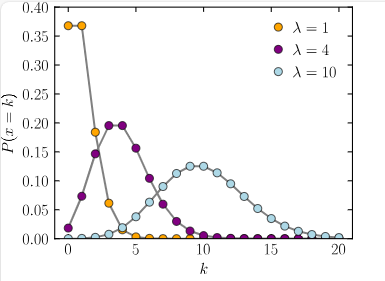


In [ ]:
NSAMPLES = np.int32(100_000)

traces = []
for lamda, color in [(1, "orange"), (4, "purple"), (10, "lightblue")]:

    dist = distributions.poisson(lam=lamda)
    distributions.sample_ints(dist, samples := np.zeros(NSAMPLES, dtype=np.int32))

    traces.append((samples[samples <= 20], f'Poisson({lamda})', color))

plot_histogram(traces)
plt.figtext(0.5, -0.05, 'The figure demonstrates that `distributions.poisson` reproduces the analytic Poisson PMF, with the mean tracking $\\lambda$ and the spread growing as $\\sqrt{\\lambda}$.', ha="center", va="top", wrap=True, fontsize=8)


## Uniform

In [ ]:
NSAMPLES = np.int32(100_000)

traces = []
for low, high, color in [(0.0, 1.0, "red"), (0.25, 1.25, "orange"), (0.0, 2.0, "green"), (-1.0, 1.0,"blue"), (2.71828, 3.14159, "indigo"), (1.30, 4.20, "violet")]:

    dist = distributions.uniform(low=low, high=high)
    distributions.sample_floats(dist, samples := np.zeros(NSAMPLES, dtype=np.float32))

    traces.append((samples, f'Uniform({low}, {high})', color))

plot_histogram(traces)
plt.figtext(0.5, -0.05, 'The figure demonstrates that `distributions.uniform` produces flat densities on arbitrary intervals — including offset, negative, and irrational endpoints — with the correct inverse-width normalization.', ha="center", va="top", wrap=True, fontsize=8)


## Weibull

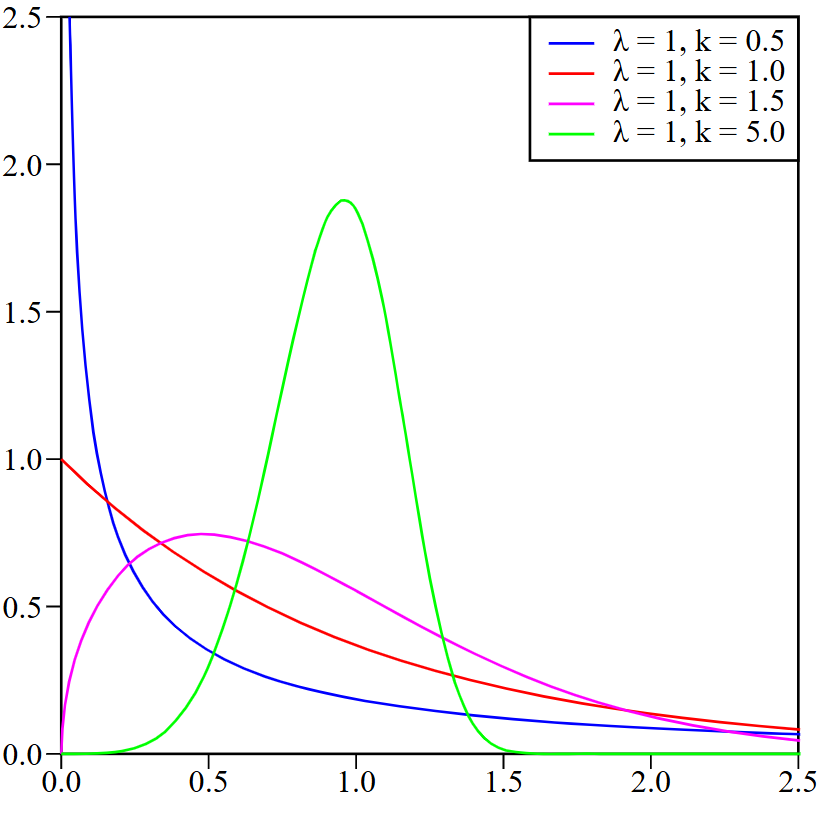


In [ ]:
NSAMPLES = np.int32(100_000)

traces = []
for k, lamda, color in [(0.5, 1.0, "blue"), (1.0, 1.0, "red"), (1.5, 1.0, "purple"), (5.0, 1.0, "green")]:

    dist = distributions.weibull(a=k, lam=lamda)
    distributions.sample_floats(dist, samples := np.zeros(NSAMPLES, dtype=np.float32))

    traces.append((samples[samples <= 2.5], f'Weibull({k}, {lamda})', color))

plot_histogram(traces)
plt.figtext(0.5, -0.05, 'The figure demonstrates that `distributions.weibull` reproduces the full Weibull family across decreasing, constant, and increasing hazard regimes, with the mode and tail behavior controlled by the shape parameter $k$.', ha="center", va="top", wrap=True, fontsize=8)
